# Deep Kalman Filter on MNIST Demo

Train a DKF to model MNIST digits as sequences of image rows.
Each 28x28 image is treated as a time series of 28 steps, each with 28-dimensional observations.

This notebook generates the MNIST reconstruction animation shown in the README.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from kalman.dkf import DeepKalmanFilter
from kalman.gaussian import GaussianState

torch.manual_seed(42)


## 1. Data

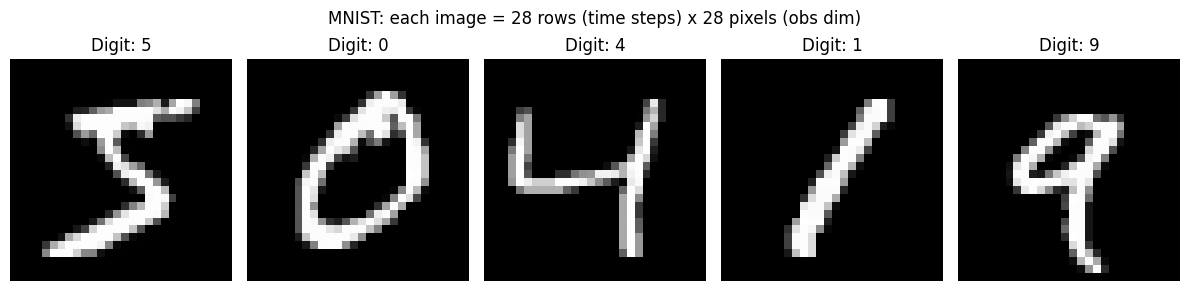

In [2]:
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_subset = torch.utils.data.Subset(train_dataset, range(5000))
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(train_dataset[i][0].squeeze(), cmap='gray')
    axes[i].set_title(f'Digit: {train_dataset[i][1]}'); axes[i].axis('off')
plt.suptitle('MNIST: each image = 28 rows (time steps) x 28 pixels (obs dim)')
plt.tight_layout(); plt.show()


## 2. Model and training

In [3]:
model = DeepKalmanFilter(
    state_dim=8, obs_dim=28,
    params={
        'dataset': 'mnist', 'transition_type': 'mlp', 'transition_layers': 2,
        'emission_type': 'mlp', 'emission_layers': 2, 'data_type': 'binary',
        'dim_hidden': 128, 'var_model': 'LR', 'rnn_size': 128, 'rnn_layers': 1,
        'inference_model': 'mean_field', 'use_prev_input': False,
    },
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Parameters: 365,516


/home/kreinin.mv/university/Kalman-filter-and-his-friends/.venv/lib/python3.10/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch  0: loss = 16482


Epoch  5: loss = 7155


Epoch 10: loss = 8354


Epoch 15: loss = 8192


Epoch 19: loss = 8103


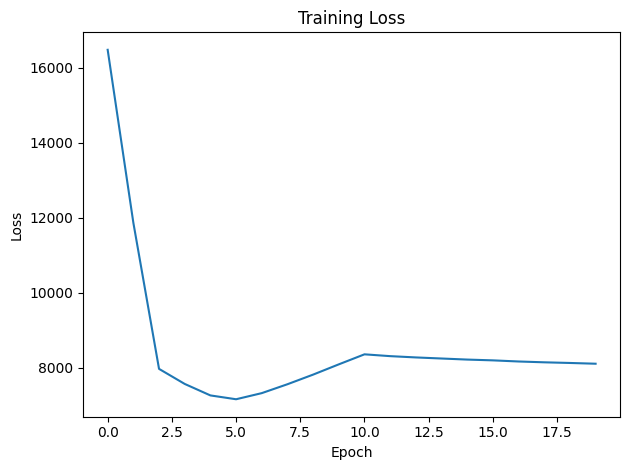

In [4]:
n_epochs = 20
history = []

for epoch in range(n_epochs):
    model.train()
    model.anneal = min(1.0, epoch / 10.0)
    epoch_loss = 0
    n = 0
    for data, _ in train_loader:
        x = data.squeeze(1).permute(1, 0, 2)  # (28, B, 28)
        mask = torch.ones(x.shape[0], x.shape[1])
        optimizer.zero_grad()
        loss, nll, kl = model.loss(x, mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        epoch_loss += loss.item()
        n += 1
    history.append(epoch_loss / n)
    if epoch % 5 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch:2d}: loss = {history[-1]:.0f}")

plt.plot(history); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training Loss')
plt.tight_layout(); plt.show()


## 3. Reconstruction

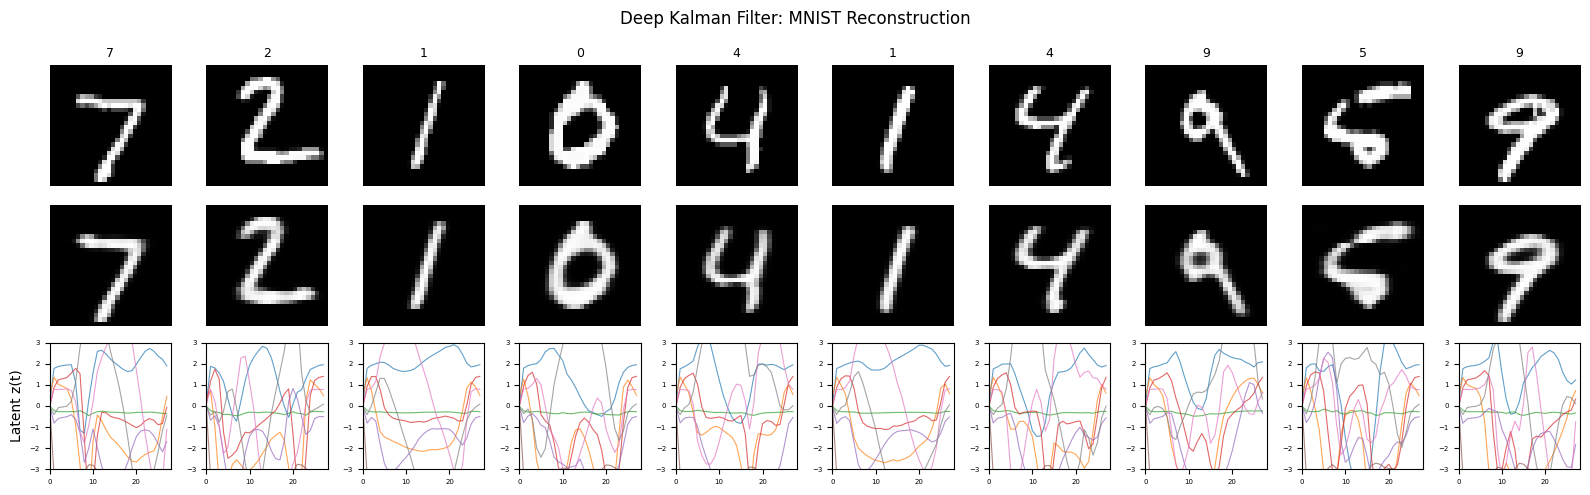

In [5]:
model.eval()
test_data, test_labels = next(iter(test_loader))
test_images = test_data.squeeze(1)
x = test_images.permute(1, 0, 2)

with torch.no_grad():
    z, mu, log_var = model.infer(x)
    z_state = GaussianState(mu, torch.ones_like(mu))
    recon, _ = model._get_emission(z_state)

n_show = 10
fig, axes = plt.subplots(3, n_show, figsize=(16, 5))
for i in range(n_show):
    axes[0, i].imshow(test_images[i].numpy(), cmap='gray'); axes[0, i].axis('off')
    axes[0, i].set_title(str(test_labels[i].item()), fontsize=9)
    axes[1, i].imshow(recon[:, i].numpy(), cmap='gray'); axes[1, i].axis('off')
    # Latent
    for d in range(min(8, mu.shape[-1])):
        axes[2, i].plot(mu[:, i, d].numpy(), lw=0.8, alpha=0.7)
    axes[2, i].set_xlim(0, 28); axes[2, i].set_ylim(-3, 3)
    axes[2, i].tick_params(labelsize=5)

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('DKF Recon', fontsize=10)
axes[2, 0].set_ylabel('Latent z(t)', fontsize=10)
plt.suptitle('Deep Kalman Filter: MNIST Reconstruction'); plt.tight_layout(); plt.show()


## 4. Latent space

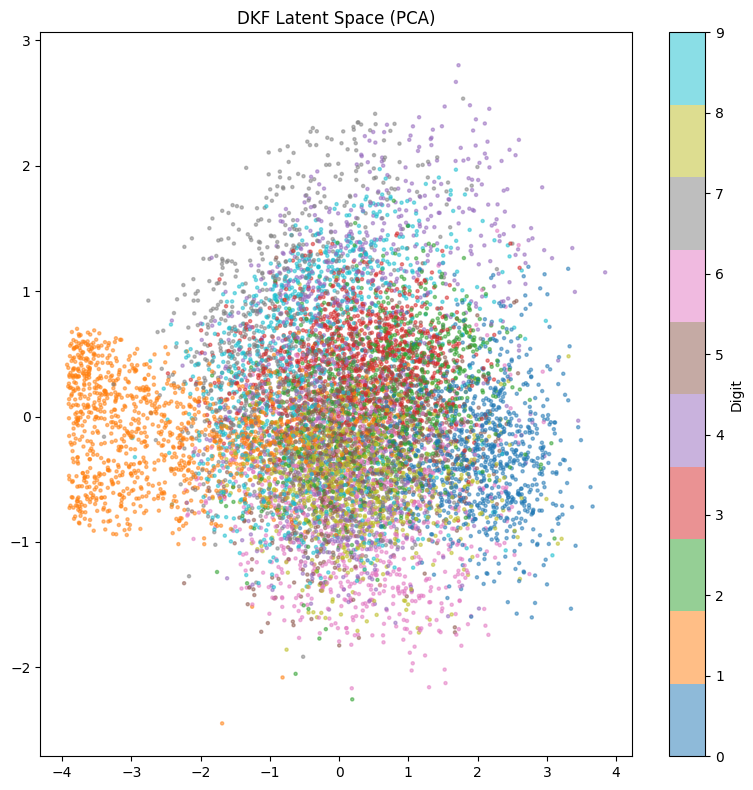

In [6]:
from sklearn.decomposition import PCA

all_z, all_labels = [], []
with torch.no_grad():
    for data, labels in test_loader:
        x = data.squeeze(1).permute(1, 0, 2)
        _, mu_batch, _ = model.infer(x)
        all_z.append(mu_batch.mean(dim=0).numpy())
        all_labels.append(labels.numpy())

all_z = np.concatenate(all_z)
all_labels = np.concatenate(all_labels)
z_2d = PCA(n_components=2).fit_transform(all_z)

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(z_2d[:,0], z_2d[:,1], c=all_labels, cmap='tab10', s=5, alpha=0.5)
plt.colorbar(scatter, label='Digit')
ax.set_title('DKF Latent Space (PCA)'); plt.tight_layout(); plt.show()
